# 5주차 — 처음부터 사전학습 → Full Fine-tuning

이번 실습은 두 단계만 진행한다.

1. **Pretraining from scratch:** TinyStories의 텍스트를 읽어 무작위 가중치의 작은 GPT를 학습한다.
2. **Full fine-tuning:** 방금 학습한 모델을 불러와 Dolly의 instruction/response 데이터로 모든 파라미터를 업데이트한다.

| 구분 | 사전학습 | Full fine-tuning (SFT) |
|---|---|---|
| 시작 가중치 | 무작위 초기화 | 앞 단계의 사전학습 체크포인트 |
| 입력 데이터 | 이야기 텍스트 | 지시문 + 선택적 문맥 + 정답 응답 |
| loss 대상 | padding을 제외한 다음 토큰 | 응답 토큰 + EOS만 |
| 업데이트 | 전체 파라미터 | 전체 파라미터 |

Colab에서는 학습 과정이 실제로 동작하는 규모로 실행한다. 짧은 학습만으로 유창한 챗봇이 만들어지는 것은 아니다.
TinyStories는 이야기 중심이고 Dolly는 다양한 지시 과제이므로, 이 데이터 조합의 목적은 두 학습 방식의 연결을 관찰하는 것이다.

## 0. 실행 환경

Colab에서 **런타임 → 런타임 유형 변경 → GPU**를 선택한다. 아래 셀부터 순서대로 실행한다.
처음에는 `PROFILE="colab"`을 사용하고, 전체 흐름 확인 후 큰 설정으로 바꾼다.
설치 전 이미 transformers를 import한 세션이라면 설치 후 런타임을 재시작한다.

In [1]:
%pip -q install "transformers==4.57.6" "accelerate==1.10.1" "datasets>=3.6,<5" "pandas>=2.2,<3" "matplotlib>=3.8,<3.11" "psutil>=5.9"
# Colab에서 제공하는 torch는 유지한다.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 30.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


### Colab / 더 큰 GPU 설정

| 프로필 | GPT 크기 (대략) | 문맥 길이 | batch × 누적 | 사전학습 / SFT step |
|---|---:|---:|---:|---:|
| colab | 16M: 4층 × 256 | 256 | 2 × 4 | 300 / 150 |
| larger | 51M: 8층 × 512 | 512 | 2 × 8 | 1,000 / 400 |
| blackwell | 124M: 12층 × 768 | 512 | 4 × 8 | 2,000 / 600 |

GPU 메모리 사용량은 실행 중 측정한다. `larger`는 VRAM 16~24GB급부터, `blackwell`은 24GB 이상에서 시도할 시작 설정이며 메모리·실행시간을 보장하지 않는다.
RAM은 데이터/CPU 공간, VRAM은 GPU 모델·gradient·optimizer·activation 공간이다. RAM이 커져도 VRAM 부족이 해결되지는 않는다.
OOM이면 batch를 먼저 줄이고 누적 횟수를 늘린다. 그래도 부족하면 문맥 길이·모델 크기를 줄인다.

Blackwell 서버는 GPU/OS/driver에 맞는 PyTorch CUDA 빌드를 설치한다.
[공식 설치 선택기](https://pytorch.org/get-started/locally/)를 이용하고 설치 후 커널을 재시작한다.
GPU 이름으로 설정을 자동 선택하지 않는다. BF16 지원 장치는 BF16, 나머지는 FP32를 사용한다.

In [2]:
import os, gc, json, math, time
from pathlib import Path
import torch
import pandas as pd
import matplotlib.pyplot as plt
import psutil
from IPython.display import display
from datasets import Dataset, load_dataset
from huggingface_hub import HfApi
from transformers import (
    AutoTokenizer, GPT2Config, GPT2LMHeadModel,
    Trainer, TrainingArguments, set_seed,
)

SEED = 42
PROFILE = "colab"  # colab / larger / blackwell
SMOKE = False      # True: 작은 데이터 + 각 2 step으로 연결만 점검
PROFILES = {
    "colab": dict(layers=4, width=256, heads=4, context=256, batch=2, accum=4,
                  pt_steps=300, sft_steps=150, pt_docs=8000, val_docs=128, sft_rows=2000),
    "larger": dict(layers=8, width=512, heads=8, context=512, batch=2, accum=8,
                   pt_steps=1000, sft_steps=400, pt_docs=40000, val_docs=256, sft_rows=8000),
    "blackwell": dict(layers=12, width=768, heads=12, context=512, batch=4, accum=8,
                      pt_steps=2000, sft_steps=600, pt_docs=100000, val_docs=256, sft_rows=12000),
}
P = PROFILES[PROFILE].copy()
if SMOKE:
    P.update(layers=1, width=32, heads=2, context=128, batch=1, accum=1,
             pt_steps=2, sft_steps=2, pt_docs=32, val_docs=8, sft_rows=100)
set_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_BF16 = DEVICE == "cuda" and torch.cuda.is_bf16_supported()
RUN_DIR = Path("week5_training") / (PROFILE + ("_smoke" if SMOKE else ""))
RUN_DIR.mkdir(parents=True, exist_ok=True)
# 다른 실험은 RUN_DIR을 바꾸어 결과를 구분한다
def write_json(path, obj):
    Path(path).write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding="utf-8")

environment = dict(torch=torch.__version__, cuda=torch.version.cuda, device=DEVICE,
    gpu=torch.cuda.get_device_name(0) if DEVICE=="cuda" else None,
    ram_gib=round(psutil.virtual_memory().total / 2**30, 1),
    vram_gib=round(torch.cuda.get_device_properties(0).total_memory / 2**30, 1) if DEVICE=="cuda" else None,
    bf16=USE_BF16, profile=P, seed=SEED)
if DEVICE=="cuda":
    probe=torch.ones((32,32),device=DEVICE)
    print("CUDA 연산 확인:", (probe @ probe).sum().item())
    del probe
else:
    print("CPU는 SMOKE=True로 확인하세요. 정규 학습에는 GPU를 권장합니다.")
display(environment)
write_json(RUN_DIR/"environment.json", environment)

CUDA 연산 확인: 32768.0


{'torch': '2.11.0+cu128',
 'cuda': '12.8',
 'device': 'cuda',
 'gpu': 'Tesla T4',
 'ram_gib': 12.7,
 'vram_gib': 14.6,
 'bf16': True,
 'profile': {'layers': 4,
  'width': 256,
  'heads': 4,
  'context': 256,
  'batch': 2,
  'accum': 4,
  'pt_steps': 300,
  'sft_steps': 150,
  'pt_docs': 8000,
  'val_docs': 128,
  'sft_rows': 2000},
 'seed': 42}

## 1. 사전학습 데이터 준비

[TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories)의 짧은 영문 이야기를 사용한다.
전체 데이터를 RAM에 올리지 않고 streaming으로 필요한 문서 수만 읽는다.
GPT-2 계열 tokenizer는 재사용하지만 **모델 가중치는 가져오지 않는다**. tokenizer와 사전학습 가중치는 별개다.
문서 뒤에 EOS를 붙이고 일정 길이 블록으로 묶는다. 마지막 불완전 블록만 제외한다.

In [3]:
TOKENIZER_ID = "distilbert/distilgpt2"
TOKENIZER_REVISION = "2290a62682d06624634c1f46a6ad5be0f47f38aa"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_ID, revision=TOKENIZER_REVISION)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
tokenizer.save_pretrained(RUN_DIR/"tokenizer")

PT_DATASET = "roneneldan/TinyStories"
SFT_DATASET = "databricks/databricks-dolly-15k"
# 최초 실행에서 revision을 기록하고, 같은 폴더 재실행 시 고정해서 재사용한다.
revision_file = RUN_DIR/"data_revisions.json"
if revision_file.exists():
    revisions=json.loads(revision_file.read_text(encoding="utf-8"))
else:
    api=HfApi()
    revisions={name:api.dataset_info(name).sha for name in [PT_DATASET,SFT_DATASET]}
    write_json(revision_file,revisions)

def story_blocks(split, document_limit):
    stream=load_dataset(PT_DATASET, split=split, streaming=True, revision=revisions[PT_DATASET])
    if split=="train": stream=stream.shuffle(seed=SEED,buffer_size=1000)
    blocks=[]; buffer=[]; total_tokens=0; documents=0
    for row in stream.take(document_limit):
        ids=tokenizer.encode(row["text"], add_special_tokens=False)+[tokenizer.eos_token_id]
        buffer.extend(ids); total_tokens+=len(ids); documents+=1
        used=0
        while len(buffer)-used>=P["context"]:
            block=buffer[used:used+P["context"]]
            blocks.append(dict(input_ids=block,attention_mask=[1]*len(block),labels=block.copy()))
            used+=P["context"]
        buffer=buffer[used:]
    assert blocks, "문서 수를 늘리세요."
    return Dataset.from_list(blocks), dict(documents=documents,raw_tokens=total_tokens,
                                         blocks=len(blocks),unused_tail_tokens=len(buffer))

pt_train,pt_train_info=story_blocks("train",P["pt_docs"])
pt_val,pt_val_info=story_blocks("validation",P["val_docs"])
display(pd.DataFrame([dict(split="train",**pt_train_info),dict(split="validation",**pt_val_info)]))
print("블록 예시:",tokenizer.decode(pt_train[0]["input_ids"][:80]))
write_json(RUN_DIR/"pretraining_data.json",dict(train=pt_train_info,validation=pt_val_info))

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1037 > 1024). Running this sequence through the model will result in indexing errors


,split,documents,raw_tokens,blocks,unused_tail_tokens
0,train,8000,1782140,6961,124
1,validation,128,22121,86,105


블록 예시: Once upon a time, there was a little mouse named Timmy. Timmy was very thin and he always felt hungry. One day, he saw a big hotel and decided to go inside to find some food. When he got inside, he saw a big piece of cheese on a table. He wanted to eat it, but he knew he had to be careful because there were many people around.


## 2. 무작위 초기화 모델을 전체 사전학습

`GPT2LMHeadModel(config)`로 모델을 새로 만든다. 모든 파라미터가 학습 대상이다.
입력과 같은 토큰을 labels로 주면 모델 내부에서 한 토큰 shift하여 다음 토큰 loss를 계산한다.
`max_steps`는 optimizer 업데이트 횟수다. 데이터가 먼저 소진되면 다음 epoch로 반복한다.
학습 전후 validation loss와 같은 프롬프트의 생성을 비교한다.

In [4]:
def causal_collator(rows):
    # pad와 EOS의 ID가 같아도 실제 EOS label은 보존한다.
    width=max(len(r["input_ids"]) for r in rows)
    ids=[]; masks=[]; labels=[]
    for r in rows:
        size=len(r["input_ids"]); padding=width-size
        ids.append(r["input_ids"]+[tokenizer.pad_token_id]*padding)
        masks.append([1]*size+[0]*padding)
        labels.append(r["labels"]+[-100]*padding)
    return {k:torch.tensor(v,dtype=torch.long) for k,v in
            dict(input_ids=ids,attention_mask=masks,labels=labels).items()}

def training_args(stage, steps, lr):
    interval=1 if SMOKE else min(100,steps)
    return TrainingArguments(
        output_dir=str(RUN_DIR/stage), max_steps=steps,
        per_device_train_batch_size=P["batch"], per_device_eval_batch_size=P["batch"],
        gradient_accumulation_steps=P["accum"], learning_rate=lr,
        warmup_ratio=0.05, lr_scheduler_type="cosine", weight_decay=0.01,
        max_grad_norm=1.0, bf16=USE_BF16, fp16=False,
        gradient_checkpointing=True, optim="adamw_torch",
        eval_strategy="steps", eval_steps=interval,
        save_strategy="steps", save_steps=interval, save_total_limit=2,
        logging_steps=1 if SMOKE else 25, report_to="none",
        dataloader_num_workers=0, seed=SEED, data_seed=SEED,
    )

@torch.no_grad()
def generate_text(model, prompt, new_tokens=64):
    model.eval()
    device=next(model.parameters()).device
    encoded=tokenizer(prompt,return_tensors="pt",add_special_tokens=False).to(device)
    available=model.config.n_positions-encoded.input_ids.shape[1]
    assert available>0,"프롬프트가 너무 깁니다."
    output=model.generate(**encoded,max_new_tokens=min(new_tokens,available),
                          do_sample=False,pad_token_id=tokenizer.pad_token_id,
                          eos_token_id=tokenizer.eos_token_id,use_cache=True)
    return tokenizer.decode(output[0,encoded.input_ids.shape[1]:],skip_special_tokens=True)

set_seed(SEED)
config=GPT2Config(vocab_size=len(tokenizer),n_positions=P["context"],n_ctx=P["context"],
    n_layer=P["layers"],n_embd=P["width"],n_head=P["heads"],
    bos_token_id=tokenizer.bos_token_id,eos_token_id=tokenizer.eos_token_id,
    pad_token_id=tokenizer.pad_token_id,use_cache=False)
model=GPT2LMHeadModel(config)  # 모든 가중치를 무작위 초기화한다
parameter_count=sum(p.numel() for p in model.parameters())
assert all(p.requires_grad for p in model.parameters())
print(f"전체 학습 파라미터: {parameter_count:,}")
pt_trainer=Trainer(model=model,args=training_args("pretraining",P["pt_steps"],5e-4),
    train_dataset=pt_train,eval_dataset=pt_val,data_collator=causal_collator)
STORY_PROMPT="Once upon a time, a little girl found a lost dog."
pt_before=pt_trainer.evaluate()["eval_loss"]
story_before=generate_text(model,STORY_PROMPT)
print("사전학습 전:",story_before)

전체 학습 파라미터: 16,090,880


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


사전학습 전:  pup pup pup pup pupigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenousigenous


Step,Training Loss,Validation Loss,Model Preparation Time
100,4.933700,4.552278,0.005400
200,4.416700,4.157288,0.005400
300,4.268200,4.085609,0.005400


,stage,loss
0,사전학습 전,10.818504
1,사전학습 후,4.085609


사전학습 후: 















The little girl named Lily was a time, there was a time, there was a time, there was a time, there was a time, there was a time, there was a time, there was a time, there was a time
저장 위치: /content/week5_training/colab/pretrained_model


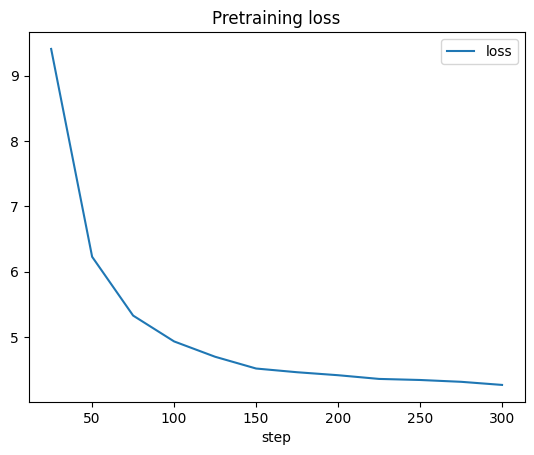

In [5]:
# 이전 중단 지점에서 재개하려면 None 대신 해당 checkpoint 폴더 경로를 지정한다.
PT_RESUME = None
if DEVICE=="cuda": torch.cuda.reset_peak_memory_stats()
pt_result=pt_trainer.train(resume_from_checkpoint=PT_RESUME)
pt_after=pt_trainer.evaluate()["eval_loss"]
story_after=generate_text(model,STORY_PROMPT)
PT_PATH=RUN_DIR/"pretrained_model"
pt_trainer.save_model(str(PT_PATH))
tokenizer.save_pretrained(PT_PATH)
pt_metrics=dict(validation_loss_before=pt_before,validation_loss_after=pt_after,
    parameters=parameter_count,train_metrics=pt_result.metrics,
    nominal_input_tokens=P["pt_steps"]*P["batch"]*P["accum"]*P["context"],
    peak_vram_gib=torch.cuda.max_memory_allocated()/2**30 if DEVICE=="cuda" else None)
write_json(RUN_DIR/"pretraining_metrics.json",pt_metrics)
write_json(RUN_DIR/"pretraining_examples.json",dict(prompt=STORY_PROMPT,before=story_before,after=story_after))
display(pd.DataFrame([dict(stage="사전학습 전",loss=pt_before),dict(stage="사전학습 후",loss=pt_after)]))
print("사전학습 후:",story_after)
print("저장 위치:",PT_PATH.resolve())
history=pd.DataFrame([r for r in pt_trainer.state.log_history if "loss" in r])
if not history.empty:
    history.plot(x="step",y="loss",title="Pretraining loss"); plt.show()
del pt_trainer, model
gc.collect()
if DEVICE=="cuda": torch.cuda.empty_cache()

## 3. Fine-tuning 데이터 준비

[Dolly 15k](https://huggingface.co/datasets/databricks/databricks-dolly-15k)의 지시문·응답을 사용한다.
입력 형식은 `Instruction → Context(있는 경우) → Response`다.
prompt는 입력에 포함하지만 **loss는 정답 응답과 EOS에만 적용**한다.
선택한 문맥 길이를 초과하는 예시는 이 실습에서는 제외하고 제외 개수를 출력한다. 무리하게 정답을 잘라 학습하지 않는다.
고정 seed로 train/validation/test를 나누고 test는 마지막 비교에만 사용한다.

In [6]:
dolly=load_dataset(SFT_DATASET,split="train",revision=revisions[SFT_DATASET])
dolly=dolly.shuffle(seed=SEED).select(range(min(P["sft_rows"],len(dolly))))

def format_prompt(row):
    prompt="### Instruction:\n"+row["instruction"].strip()+"\n"
    if row.get("context","").strip():
        prompt+="### Context:\n"+row["context"].strip()+"\n"
    return prompt+"### Response:\n"

def encode_sft(row):
    prompt_ids=tokenizer.encode(format_prompt(row),add_special_tokens=False)
    response_ids=tokenizer.encode(row["response"].strip(),add_special_tokens=False)+[tokenizer.eos_token_id]
    ids=prompt_ids+response_ids
    if not row["response"].strip() or len(ids)>P["context"]: return None
    return dict(input_ids=ids,attention_mask=[1]*len(ids),
                labels=[-100]*len(prompt_ids)+response_ids)

# 동일한 instruction/context는 서로 다른 split에 배치하지 않는다
unique_rows={}
for row in dolly:
    unique_rows.setdefault(format_prompt(row),row)
eligible=[row for row in unique_rows.values() if encode_sft(row) is not None]
assert len(eligible)>=10,"유효한 예시가 부족합니다. sft_rows 또는 context를 늘리세요."
eligible=Dataset.from_list(eligible)
split=eligible.train_test_split(test_size=0.2,seed=SEED)
heldout=split["test"].train_test_split(test_size=0.5,seed=SEED)
sft_raw={"train":split["train"],"validation":heldout["train"],"test":heldout["test"]}
sft_data={key:Dataset.from_list([encode_sft(row) for row in rows]) for key,rows in sft_raw.items()}
print("읽은 행:",len(dolly),"동일 prompt 중복 제외:",len(dolly)-len(unique_rows),
      "길이/빈 응답 제외:",len(unique_rows)-len(eligible))
print("사용 개수:",{key:len(rows) for key,rows in sft_data.items()})
example=sft_data["train"][0]
assert example["labels"][0]==-100
assert example["labels"][-1]==tokenizer.eos_token_id
print("모델 입력:\n",tokenizer.decode(example["input_ids"]))
print("loss 대상:\n",tokenizer.decode([i for i in example["labels"] if i!=-100]))

README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

읽은 행: 2000 동일 prompt 중복 제외: 6 길이/빈 응답 제외: 417
사용 개수: {'train': 1261, 'validation': 158, 'test': 158}
모델 입력:
 ### Instruction:
Why do people get married?
### Response:
People get married for a variety of reasons. Most people get married because they feel like they are in love with the other person and want to spend the rest of their life with that person. Many people get married because they want to start a family. Some get married in order to have tax advantages and legal protection.<|endoftext|>
loss 대상:
 People get married for a variety of reasons. Most people get married because they feel like they are in love with the other person and want to spend the rest of their life with that person. Many people get married because they want to start a family. Some get married in order to have tax advantages and legal protection.<|endoftext|>


## 4. 전체 파라미터 Fine-tuning

`pretrained_model` 폴더에서 앞 단계의 가중치를 불러온다. 모델을 새로 초기화하지 않는다.
모든 파라미터를 업데이트하며, LoRA나 양자화는 사용하지 않는다.
같은 tokenizer·모델 구조를 유지하고 데이터 형식과 loss 대상, 학습률을 바꾼다.

In [7]:
model=GPT2LMHeadModel.from_pretrained(PT_PATH)
model.config.use_cache=False
for param in model.parameters(): param.requires_grad_(True)
total=sum(p.numel() for p in model.parameters())
trainable=sum(p.numel() for p in model.parameters() if p.requires_grad)
assert trainable==total==parameter_count
print(f"Full fine-tuning: {trainable:,} / {total:,} ({trainable/total:.0%})")

sft_trainer=Trainer(model=model,args=training_args("finetuning",P["sft_steps"],5e-5),
    train_dataset=sft_data["train"],eval_dataset=sft_data["validation"],
    data_collator=causal_collator)
sft_before=sft_trainer.evaluate()["eval_loss"]
# 예시 비교는 validation에서 고정한다. 학습 설정 선택에 test는 사용하지 않는다.
demo_rows=list(sft_raw["validation"].select(range(min(3,len(sft_raw["validation"])))) )
demo_before=[generate_text(model,format_prompt(row)) for row in demo_rows]
print("SFT 전 validation 응답 loss:",sft_before)

Full fine-tuning: 16,090,880 / 16,090,880 (100%)


SFT 전 validation 응답 loss: 8.719141006469727


Step,Training Loss,Validation Loss,Model Preparation Time
100,7.493000,7.784825,0.000900


,stage,response_loss
0,SFT 전 validation,8.719141
1,SFT 후 validation,7.765389
2,SFT 후 test,7.682072


지시: What is handscroll used for 
이전: 














































The little girl named Lily was so happy and said, "I'm so happy and 
이후: 






The little girl named 
정답: The handscroll is a long, narrow, horizontal scroll format in East Asia used for calligraphy or paintings. 

지시: What is a mediterranean diet? 
이전: 












The little girl named Lily was so happy and said, "I'm not want to the park. They were very happy. They were very happy. They were very happy and said, "I'm not want to the park. They were very happy. 
이후: 
The little girl named 
정답: The mediterranean diet consists of traditional foods from countries bordering the mediterranean sea, such as Greece, France, and Italy. The diet typically contains fruits, vegetables, whole grains, lentils, nuts, and seeds. Extra-virgin olive oil is a typical source of healthy fats. The diet does not contain heavily processed foods, products with added sugar, or large amounts of unhealthy fats as found in butte

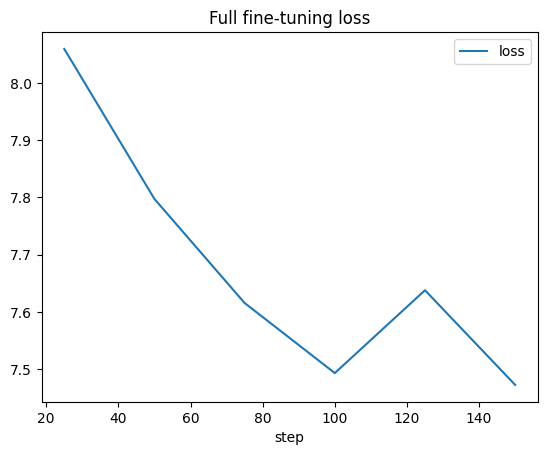

최종 모델: /content/week5_training/colab/finetuned_model


In [8]:
SFT_RESUME = None
if DEVICE=="cuda": torch.cuda.reset_peak_memory_stats()
sft_result=sft_trainer.train(resume_from_checkpoint=SFT_RESUME)
sft_after=sft_trainer.evaluate()["eval_loss"]
sft_test=sft_trainer.evaluate(sft_data["test"],metric_key_prefix="test")["test_loss"]
demo_after=[generate_text(model,format_prompt(row)) for row in demo_rows]
FT_PATH=RUN_DIR/"finetuned_model"
sft_trainer.save_model(str(FT_PATH))
tokenizer.save_pretrained(FT_PATH)
sft_metrics=dict(validation_response_loss_before=sft_before,validation_response_loss_after=sft_after,
    test_response_loss=sft_test,trainable_parameters=trainable,
    train_metrics=sft_result.metrics,
    peak_vram_gib=torch.cuda.max_memory_allocated()/2**30 if DEVICE=="cuda" else None)
write_json(RUN_DIR/"finetuning_metrics.json",sft_metrics)
comparison=[dict(instruction=row["instruction"],context=row["context"],reference=row["response"],
                 before=before,after=after) for row,before,after in zip(demo_rows,demo_before,demo_after)]
write_json(RUN_DIR/"finetuning_examples.json",comparison)
display(pd.DataFrame([dict(stage="SFT 전 validation",response_loss=sft_before),
    dict(stage="SFT 후 validation",response_loss=sft_after),dict(stage="SFT 후 test",response_loss=sft_test)]))
for item in comparison:
    print("지시:",item["instruction"],"\n이전:",item["before"],"\n이후:",item["after"],"\n정답:",item["reference"],"\n")
history=pd.DataFrame([r for r in sft_trainer.state.log_history if "loss" in r])
if not history.empty:
    history.plot(x="step",y="loss",title="Full fine-tuning loss"); plt.show()
print("최종 모델:",FT_PATH.resolve())

## 5. 학습한 모델에 직접 질문하기

학습할 때와 같은 입력 형식을 사용한다. 아래 instruction을 바꿔 실행해 본다.

In [9]:
my_request={"instruction":"Write a short story about a dog and a little girl.","context":""}
print(generate_text(model,format_prompt(my_request),new_tokens=100))

The little girl named


### 더 길게 학습할 때

- `pt_docs`는 읽는 고유 문서 수, `pt_steps`는 학습 업데이트 수다. steps만 늘리면 같은 데이터를 더 반복할 수 있다.
- 사전학습은 원문 전체, SFT는 정답 응답만 loss를 계산한다. 두 단계의 loss 숫자를 직접 비교하지 말고 각 단계의 전후를 비교한다. Trainer의 평가 loss는 배치 단위 평균이므로 엄밀한 코퍼스 token-weighted perplexity로 보고하지 않는다.
- 큰 GPU에서는 우선 문서 수와 학습 step을 늘리고, VRAM을 측정하며 모델·문맥·batch를 확장한다. 이 코드는 단일 GPU 기준이다.
- `week5_training/.../pretraining/checkpoint-*`와 `finetuning/checkpoint-*`에는 재개 상태가 저장된다. 해당 단계의 `*_RESUME`에 경로를 넣으면 된다. 같은 설정·데이터·revision으로 재개한다.
- `pretrained_model`과 `finetuned_model`은 모델·tokenizer 저장본이다. Colab 종료 전에 필요한 폴더를 Drive 등 지속 저장소에 보관한다.
- 이 설정은 작은 모델의 학습 실습이다. TinyStories 일부와 짧은 SFT만으로 광범위한 지시 수행 능력을 기대하지 않는다.

데이터 출처: [TinyStories (CDLA-Sharing-1.0)](https://huggingface.co/datasets/roneneldan/TinyStories),
[Dolly 15k (CC-BY-SA-3.0)](https://huggingface.co/datasets/databricks/databricks-dolly-15k).
학습 API: [GPT-2](https://huggingface.co/docs/transformers/v4.57.1/en/model_doc/gpt2),
[Trainer](https://huggingface.co/docs/transformers/v4.57.1/en/main_classes/trainer).